# ALMA visibility inspection -- NGC 3110 and NGC 2369

Project **2017.1.00255.S**, band 6 (CO(2-1) region, ~226-245 GHz), EU ARC
CalMS-service downloads under `/nas/datasets/ALMA_visibilities`.

| galaxy | MOUS | config | EB(s) | resolution |
|---|---|---|---|---|
| NGC 3110 | `uid://A001/X1284/X1371` | 12m extended | `uid___A002_Xc7cf4e_X7866` | 0.13" |
| NGC 3110 | `uid://A001/X1284/X1373` | 12m compact | `uid___A002_Xcf92df_X4e8e`, `uid___A002_Xd09670_X3f8d` | 0.82" |
| NGC 2369 | `uid://A001/X1284/X136b` | 12m extended | `uid___A002_Xc845c0_X1710` | 0.15" |
| NGC 2369 | `uid://A001/X1284/X136d` | 12m compact | `uid___A002_Xcd07af_X20e` | 0.90" |

Each galaxy's compact and extended MOUSs share one GOUS (confirmed via the
ALMA TAP `obscore` table, not just the MOUS-name pattern), but **the two
configurations are treated as distinct datasets throughout** -- never gridded
together. NGC 3110's compact configuration was observed in two execution
blocks, so its compact dataset is two MSs gridded jointly (both calibrated
with casapipe-5.1.1, so their `WEIGHT` columns share one scale).

Three views, each one figure with a row per configuration (extended, compact)
and a column per galaxy (NGC 3110, NGC 2369):

1. **(u, v) coverage** -- read straight from the `UVW` column, not gridded.
2. **Dirty image** -- natural-weighted continuum (all 4 science spws, MFS),
   niter=0: a single grid + FFT, no CLEAN.
3. **Dirty beam (PSF)** -- same weighting/gridding, response to a point source.

Both configurations of a galaxy are imaged on **one common pixel grid** --
same phase centre, same 0.02" cells, same 48" field -- so their dirty images
and beams can be compared pixel for pixel. Dirty image and dirty beam are saved as FITS under
`data/<galaxy>/<config>/`.

In [1]:
import glob
import os
import shutil
import sys

import numpy as np
import matplotlib.pyplot as plt


# cwd is notebooks/ -- true when this cell runs inside build_and_execute()
# (chdir_to_notebooks=True below) *and* when this .ipynb is later opened in a
# real Jupyter session launched from notebooks/, which is the normal way to
# open a file browsed to inside that folder. No `__file__` exists in either
# case (Jupyter cells don't have one, and neither does an exec()'d cell), so
# this is the only cwd-independent way to find the repo root available here.
REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, os.path.join(REPO_ROOT, "simple"))

from casatools import msmetadata, table, image, quanta, regionmanager
from casatasks import tclean
from casa_logs import redirect_casa_logs
redirect_casa_logs("alma_visibility_inspection.log")

VIS_ROOT = "/nas/datasets/ALMA_visibilities"

# One entry per configuration; each is its own dataset. A configuration with
# several execution blocks (NGC 3110 compact) lists all its MSs -- they are
# gridded together, and the first one's `field` sets the phase centre.
GALAXIES = [
    dict(
        label="NGC 3110",
        key="ngc3110",
        field="ngc3110",
        configs=dict(
            extended=[f"{VIS_ROOT}/gal1/NGC3110_12m_extended_X1371/uid___A002_Xc7cf4e_X7866.ms.split.cal"],
            compact=[f"{VIS_ROOT}/gal1/NGC3110_12m_compact_X1373/uid___A002_Xcf92df_X4e8e.ms.split.cal",
                     f"{VIS_ROOT}/gal1/NGC3110_12m_compact_X1373/uid___A002_Xd09670_X3f8d.ms.split.cal"],
        ),
    ),
    dict(
        label="NGC 2369",
        key="ngc2369",
        field="ngc2369",
        configs=dict(
            extended=[f"{VIS_ROOT}/gal2/NGC2369_12m_extended_X136b/uid___A002_Xc845c0_X1710.ms.split.cal"],
            compact=[f"{VIS_ROOT}/gal2/NGC2369_12m_compact_X136d/uid___A002_Xcd07af_X20e.ms.split.cal"],
        ),
    ),
]

CONFIGS = ("extended", "compact")

# ONE pixel grid shared by both configurations (and the same phase centre,
# see `phasecenter_string`), so compact and extended images line up pixel
# for pixel. 0.02" cells: ~7 px across the 0.13-0.15" extended beam (and
# ~40 across the 0.8-0.9" compact one). 2400 px -> 48" field, spanning the
# ~25" band-6 primary beam FWHM so no compact emission is cut off.
IMSIZE = 2400
CELL_ARCSEC = 0.02

# Every figure shows all panels over the same sky window, so structures
# compare at equal angular scale: the full 48" field, a CROP_ARCSEC-wide
# crop (also written as *_16arcsec.fits next to the full-field FITS), and
# for dirty beams a +/-PSF_ZOOM_ARCSEC main-lobe zoom.
CROP_ARCSEC = 16.0
PSF_ZOOM_ARCSEC = 1.5

# REUSE_FITS=1 in the environment: load this grid's existing FITS instead of
# re-running tclean (~15 min) -- for figure-only changes. Leave unset after
# changing MSs, weighting or grid, or the figures will show stale images.
REUSE_FITS = os.environ.get("REUSE_FITS") == "1"
WEIGHTING = "natural"

missing = [p for g in GALAXIES for paths in g["configs"].values() for p in paths
           if not os.path.isdir(p)]
if missing:
    raise FileNotFoundError(
        "MS(s) not found -- run scripts/download_ngc3110_compact.sh / "
        "download_ngc2369_compact.sh first:\n  " + "\n  ".join(missing)
    )

for g in GALAXIES:
    print(f"{g['label']:<10} field={g['field']!r}")
    for config, paths in g["configs"].items():
        os.makedirs(os.path.join(REPO_ROOT, "data", g["key"], config), exist_ok=True)
        print(f"    {config:<9} " + ", ".join(os.path.basename(p) for p in paths))

NGC 3110   field='ngc3110'
    extended  uid___A002_Xc7cf4e_X7866.ms.split.cal
    compact   uid___A002_Xcf92df_X4e8e.ms.split.cal, uid___A002_Xd09670_X3f8d.ms.split.cal
NGC 2369   field='ngc2369'
    extended  uid___A002_Xc845c0_X1710.ms.split.cal
    compact   uid___A002_Xcd07af_X20e.ms.split.cal


In [2]:
def science_spws(msname):
    '''Science spectral windows (excludes WVR / channel-avg windows).'''
    md = msmetadata()
    md.open(msname)
    try:
        spws = [s for s in md.spwsforintent("OBSERVE_TARGET#ON_SOURCE") if md.nchan(s) > 1]
    finally:
        md.close()
    return spws


def field_id(msname, field):
    md = msmetadata()
    md.open(msname)
    try:
        ids = md.fieldsforname(field)
        if len(ids) == 0:
            raise ValueError(f"no field {field!r} in {msname}; fields: {md.fieldnames()}")
        return int(ids[0])
    finally:
        md.close()


def uv_coverage_klambda(msname, field):
    '''(u, v) of every unflagged science-spw row for `field`, in k-lambda,
    each row's baseline converted using that row's spw mean frequency (so the
    plot reflects the true frequency-dependent uv coverage of the continuum
    image built from all spws, not one representative frequency).'''
    fid = field_id(msname, field)
    spws = science_spws(msname)

    md = msmetadata()
    md.open(msname)
    try:
        meanfreq = {s: float(md.meanfreq(s)) for s in spws}
    finally:
        md.close()

    tb = table()
    tb.open(os.path.join(msname, "DATA_DESCRIPTION"))
    dd_spw = tb.getcol("SPECTRAL_WINDOW_ID")
    tb.close()
    sci_dd = {d for d, s in enumerate(dd_spw) if s in spws}

    tb.open(msname)
    sub = tb.query(f"FIELD_ID=={fid} && !FLAG_ROW", columns="UVW,DATA_DESC_ID")
    uvw = sub.getcol("UVW")            # (3, nrow) metres
    ddid = sub.getcol("DATA_DESC_ID")
    sub.close()
    tb.close()

    mask = np.isin(ddid, list(sci_dd))
    freq = np.array([meanfreq[dd_spw[d]] for d in ddid[mask]])
    c = 2.99792458e8
    u_kl = uvw[0, mask] * freq / c / 1e3
    v_kl = uvw[1, mask] * freq / c / 1e3
    return u_kl, v_kl


def phasecenter_string(msname, field):
    '''`field`'s phase centre in `msname` as a tclean direction string, so
    several tclean runs can be pinned to exactly the same image centre.'''
    md = msmetadata()
    md.open(msname)
    try:
        d = md.phasecenter(field_id(msname, field))
    finally:
        md.close()
    qa = quanta()
    return (f"{d['refer']} {qa.time(d['m0'], prec=11)[0]} "
            f"{qa.angle(d['m1'], prec=10)[0]}")


def make_dirty_and_psf(msname_list, field, phasecenter, out_dir,
                        imsize=IMSIZE, cell_arcsec=CELL_ARCSEC, weighting=WEIGHTING):
    '''Natural-weighted, niter=0 continuum dirty image + PSF (all science
    spws of every MS combined, MFS) via `tclean(niter=0)` -- the CASA
    gridder/FFT with no deconvolution. All MSs in `msname_list` (the EBs of
    ONE configuration) are gridded onto one grid, each visibility weighted by
    its own WEIGHT column, so their relative contribution follows their
    sensitivities. Returns the two images
    as (ny, nx) numpy arrays (already transposed/flipped into
    imshow(origin='lower') + RA-left convention) plus the FITS paths written.

    `spw` is passed per MS because science spw ids need not agree between EBs.
    `phasecenter` is an explicit direction string (see `phasecenter_string`),
    so every call given the same one lands on the same pixel grid.'''
    spw_sel = [",".join(str(s) for s in science_spws(ms)) for ms in msname_list]

    base = os.path.join(out_dir, "_tclean")
    for p in glob.glob(base + ".*"):
        shutil.rmtree(p)
    tclean(vis=list(msname_list), field=field, spw=spw_sel, datacolumn="data",
           imagename=base, imsize=imsize, cell=f"{cell_arcsec}arcsec",
           phasecenter=phasecenter, specmode="mfs", gridder="standard",
           weighting=weighting, niter=0, restoration=False, pbcor=False)
    dirty_casa, psf_casa = base + ".residual", base + ".psf"   # niter=0: residual == dirty

    ia = image()
    fits_paths = fits_outputs(out_dir)
    for casa_path, fits_path in ((dirty_casa, fits_paths["dirty"]),
                                  (psf_casa, fits_paths["psf"])):
        ia.open(casa_path)
        ia.tofits(fits_path, overwrite=True)
        ia.close()
    for p in glob.glob(base + ".*"):
        shutil.rmtree(p)

    return read_plane(fits_paths["dirty"]), read_plane(fits_paths["psf"]), fits_paths


def fits_outputs(out_dir):
    return dict(dirty=os.path.join(out_dir, "dirty_image.fits"),
                psf=os.path.join(out_dir, "dirty_beam.fits"))


def crop_fits(src, dst, width_arcsec, imsize=IMSIZE, cell_arcsec=CELL_ARCSEC):
    '''Write the central `width_arcsec` x `width_arcsec` of FITS `src` to `dst`
    as its own FITS, WCS intact (phase centre stays on the central pixel).'''
    half_px = int(round(width_arcsec / 2 / cell_arcsec))
    lo, hi = imsize // 2 - half_px, imsize // 2 + half_px - 1
    ia = image()
    ia.open(src)
    try:
        sub = ia.subimage(region=regionmanager().box(blc=[lo, lo], trc=[hi, hi]))
        sub.tofits(dst, overwrite=True)
        sub.done()
    finally:
        ia.close()
    return dst


def read_plane(path):
    '''First Stokes/channel plane of a CASA image or FITS file as (ny, nx):
    row = Dec, col = RA, for imshow(origin='lower') + RA-left extents.'''
    ia = image()
    ia.open(path)
    try:
        return ia.getchunk()[:, :, 0, 0].T
    finally:
        ia.close()

## 1. (u, v) coverage

Every unflagged visibility's baseline, in k$\lambda$, mirrored about the
origin (a real sky has $V(-u,-v) = V(u,v)^{*}$, so every measured point
implies its conjugate). This is what natural weighting below sees -- no
gridding or averaging yet.

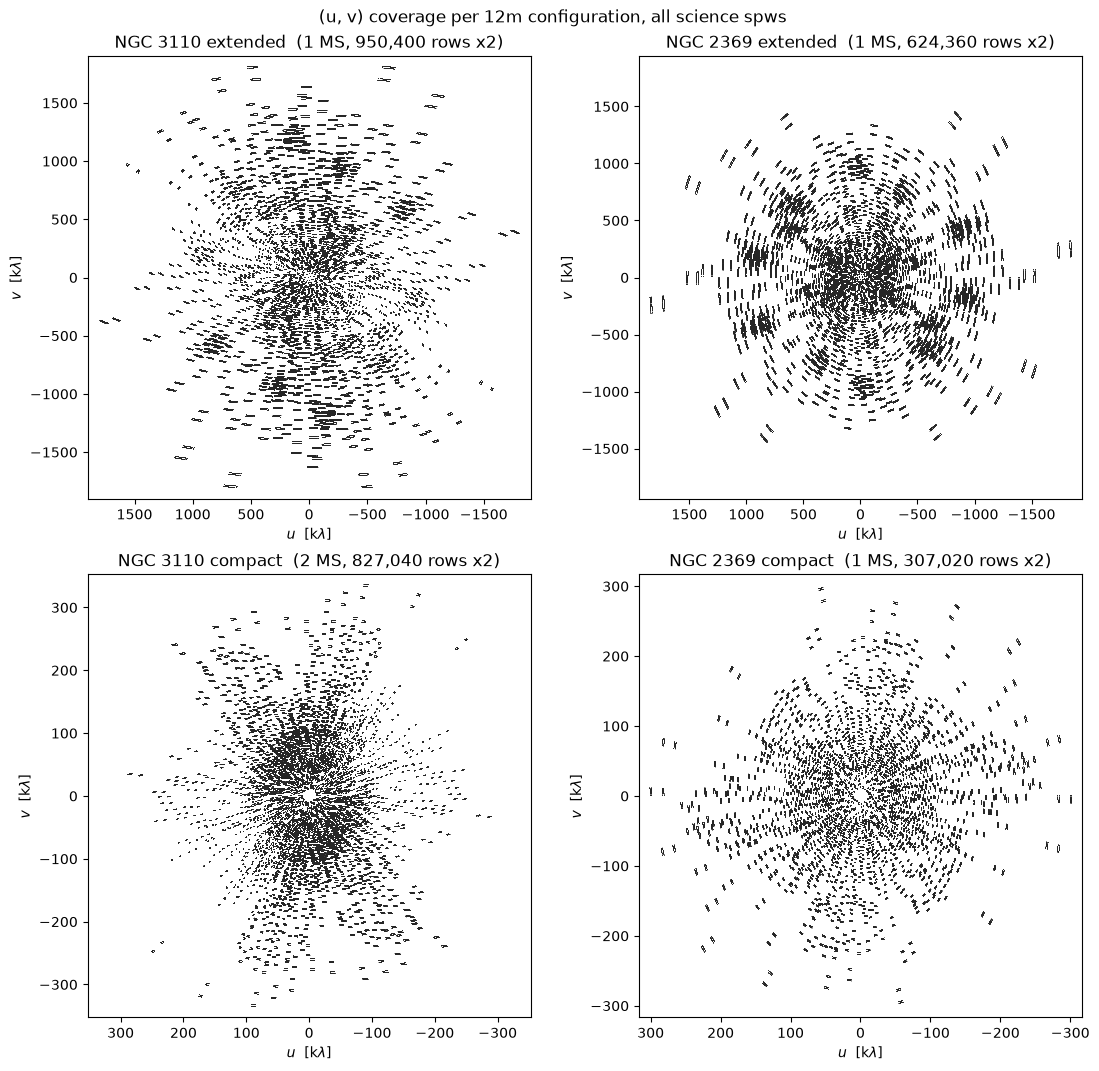

In [4]:
uv = {(g["key"], config): [uv_coverage_klambda(p, g["field"]) for p in paths]
      for g in GALAXIES for config, paths in g["configs"].items()}

fig, axes = plt.subplots(len(CONFIGS), len(GALAXIES), figsize=(11, 10.6),
                         constrained_layout=True, squeeze=False)
for row, config in enumerate(CONFIGS):
    for ax, g in zip(axes[row], GALAXIES):
        per_ms = uv[g["key"], config]
        for u, v in per_ms:
            ax.plot(u, v, ",", color="0.15", alpha=0.35, rasterized=True)
            ax.plot(-u, -v, ",", color="0.15", alpha=0.35, rasterized=True)
        lim = 1.05 * max(max(np.abs(u).max(), np.abs(v).max()) for u, v in per_ms)
        nrow = sum(u.size for u, _ in per_ms)
        ax.set_xlim(lim, -lim)   # RA-style convention: u increasing to the left
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(r"$u$  [k$\lambda$]")
        ax.set_ylabel(r"$v$  [k$\lambda$]")
        ax.set_title(f"{g['label']} {config}  ({len(per_ms)} MS, {nrow:,} rows x2)")
fig.suptitle("(u, v) coverage per 12m configuration, all science spws")
plt.show()

## 2. Dirty image and dirty beam

Continuum (all 4 science spws combined, multi-frequency synthesis), natural
weighting, `niter=0` -- a single grid + FFT of the observed visibilities, with
no CLEAN deconvolution, done separately for each configuration. This is the
true resolution/sidelobe structure each dataset alone gives you: the extended
data resolve ~0.13-0.15" but miss emission larger than their ~3.6-4" largest
recoverable scale (per `assess_ms`); the compact data see that larger-scale
emission at ~0.8-0.9" resolution. Both rows share one pixel grid and every
panel of a figure shows the same sky window, so structures compare at equal
angular scale. Each figure
comes twice: the full 48" field, then cropped to the central 16" (the crop
is also saved as its own FITS).

In [6]:
results = {}
for g in GALAXIES:
    # Both configurations pinned to the extended MS's phase centre.
    phasecenter = phasecenter_string(g["configs"]["extended"][0], g["field"])
    print(f"[{g['label']}] phase centre {phasecenter}")
    for config, paths in g["configs"].items():
        tag = f"[{g['label']} {config}]"
        out_dir = os.path.join(REPO_ROOT, "data", g["key"], config)
        fits_paths = fits_outputs(out_dir)
        if REUSE_FITS and all(os.path.exists(f) for f in fits_paths.values()):
            dirty, psf = read_plane(fits_paths["dirty"]), read_plane(fits_paths["psf"])
            if dirty.shape != (IMSIZE, IMSIZE):
                raise ValueError(f"{tag} existing FITS are {dirty.shape}, not "
                                 f"{IMSIZE}x{IMSIZE} -- rebuild without REUSE_FITS=1")
            print(f"{tag} REUSE_FITS=1: loaded {fits_paths['dirty']} (+ dirty_beam.fits)")
        else:
            print(f"{tag} gridding {len(paths)} MS -> {IMSIZE}x{IMSIZE} px "
                  f"@ {CELL_ARCSEC}\" ({WEIGHTING} weighting) ...")
            dirty, psf, fits_paths = make_dirty_and_psf(paths, g["field"], phasecenter, out_dir)
            print(f"{tag} wrote {fits_paths['dirty']}")
            print(f"{tag} wrote {fits_paths['psf']}")
        results[g["key"], config] = dict(dirty=dirty, psf=psf, fits=fits_paths)

[NGC 3110] phase centre ICRS 10:04:02.12400 -006.28.29.1200
[NGC 3110 extended] REUSE_FITS=1: loaded /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc3110/extended/dirty_image.fits (+ dirty_beam.fits)
[NGC 3110 compact] REUSE_FITS=1: loaded /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc3110/compact/dirty_image.fits (+ dirty_beam.fits)
[NGC 2369] phase centre ICRS 07:16:37.75300 -062.20.37.5100
[NGC 2369 extended] REUSE_FITS=1: loaded /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc2369/extended/dirty_image.fits (+ dirty_beam.fits)
[NGC 2369 compact] REUSE_FITS=1: loaded /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc2369/compact/dirty_image.fits (+ dirty_beam.fits)


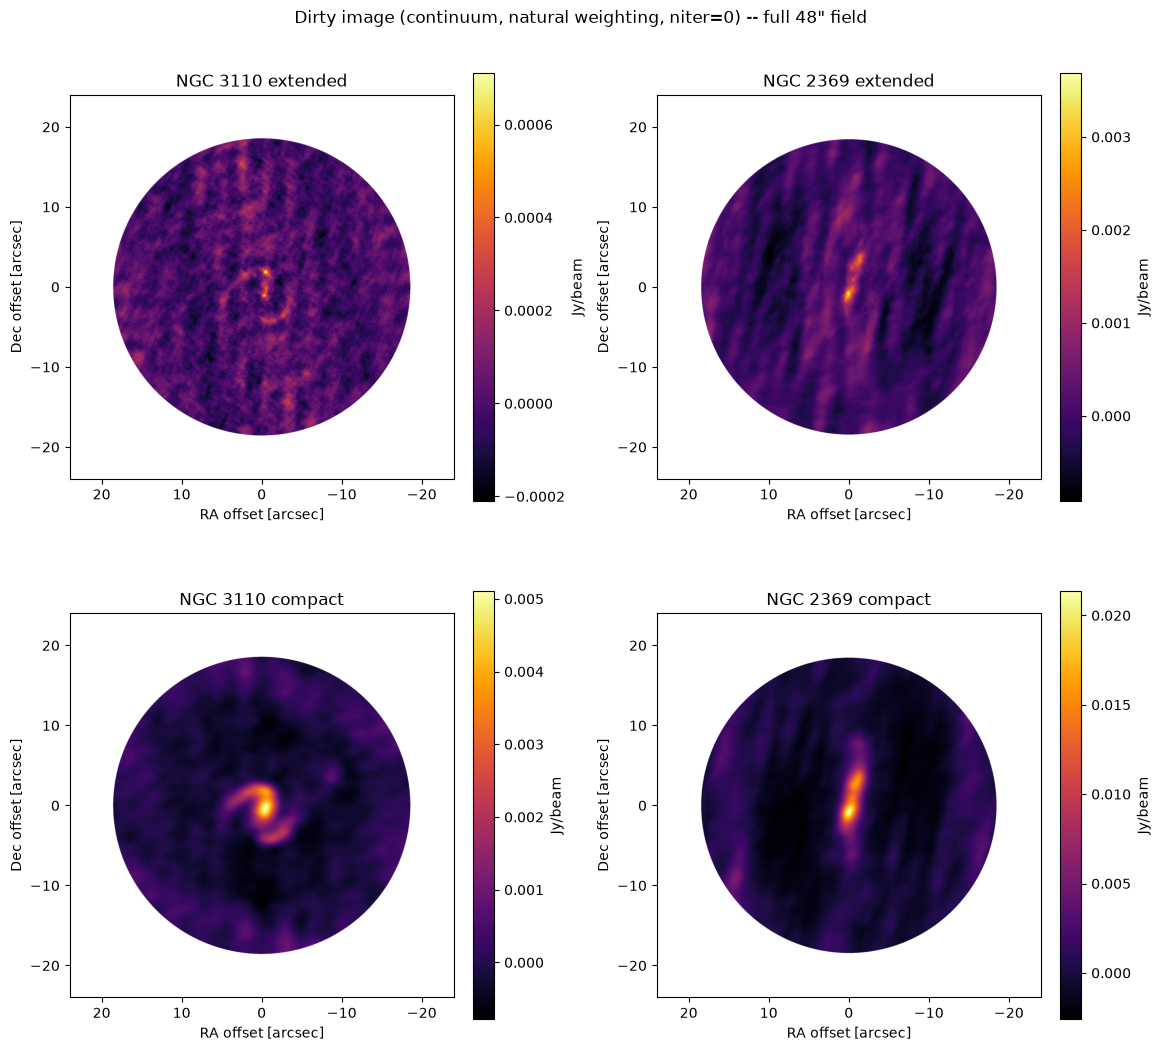

In [7]:
FULL_HALF = IMSIZE / 2 * CELL_ARCSEC
EXTENT = [FULL_HALF, -FULL_HALF, -FULL_HALF, FULL_HALF]   # same grid for every panel


def show_panels(kind, half_view, title, cbar_label, **imshow_kw):
    '''One figure: a row per configuration, a column per galaxy, every panel
    showing `results[...][kind]` over the same +/-half_view arcsec window.'''
    fig, axes = plt.subplots(len(CONFIGS), len(GALAXIES), figsize=(11.5, 10.6),
                             constrained_layout=True, squeeze=False)
    for row, config in enumerate(CONFIGS):
        for ax, g in zip(axes[row], GALAXIES):
            im = ax.imshow(results[g["key"], config][kind], origin="lower",
                            extent=EXTENT, **imshow_kw)
            ax.set_xlim(half_view, -half_view)
            ax.set_ylim(-half_view, half_view)
            ax.set_xlabel("RA offset [arcsec]")
            ax.set_ylabel("Dec offset [arcsec]")
            ax.set_title(f"{g['label']} {config}")
            fig.colorbar(im, ax=ax, label=cbar_label, shrink=0.85)
    fig.suptitle(title)
    plt.show()


show_panels("dirty", FULL_HALF, "Dirty image (continuum, "
            f"{WEIGHTING} weighting, niter=0) -- full {2 * FULL_HALF:.0f}\" field",
            "Jy/beam", cmap="inferno")

wrote /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc3110/extended/dirty_image_16arcsec.fits
wrote /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc3110/compact/dirty_image_16arcsec.fits
wrote /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc2369/extended/dirty_image_16arcsec.fits
wrote /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc2369/compact/dirty_image_16arcsec.fits


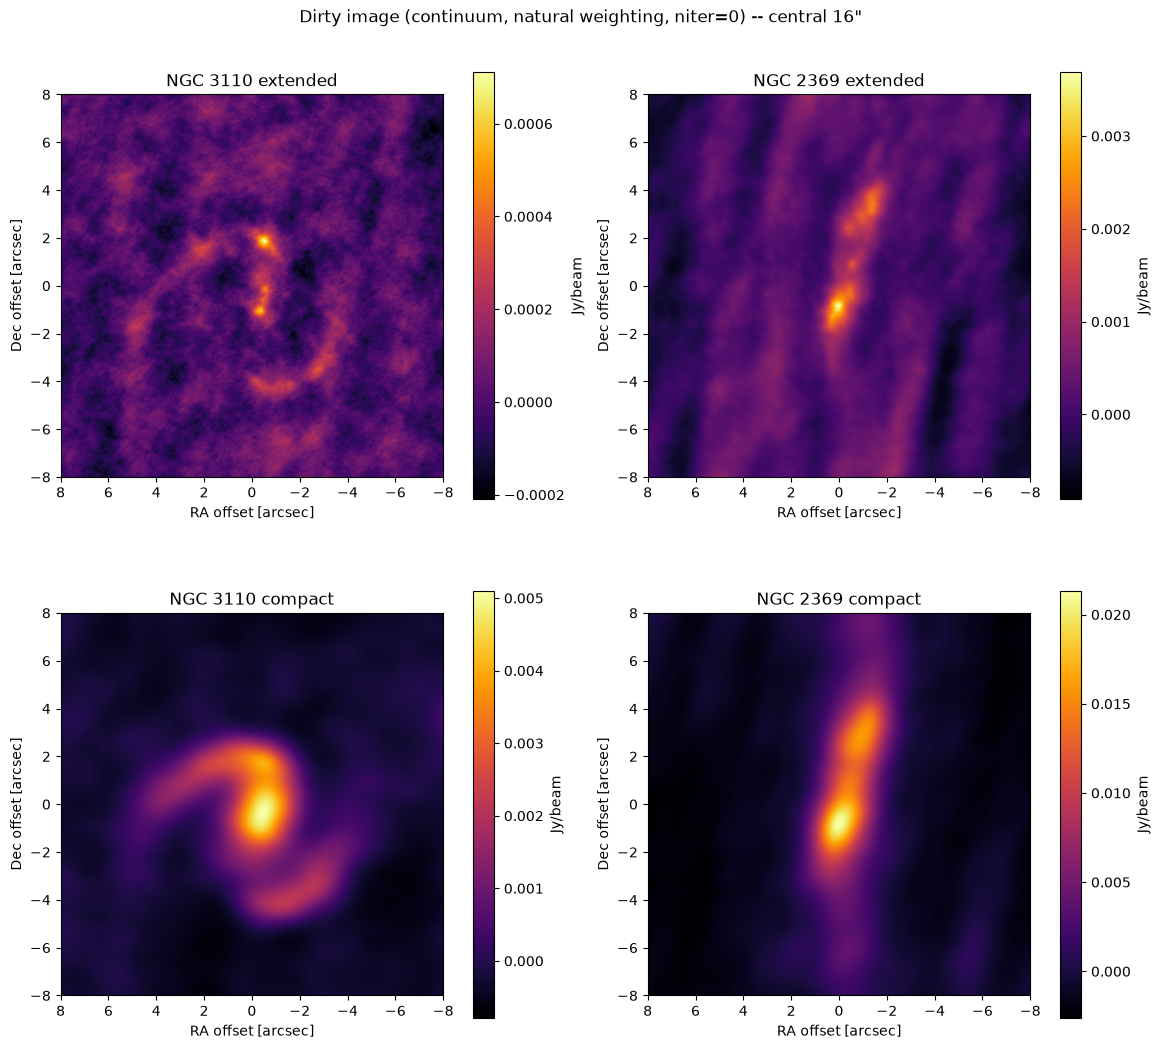

In [8]:
# Same images, cropped to the central CROP_ARCSEC, also saved as FITS next to
# the full-field ones (dirty_image_16arcsec.fits).
for (key, config), r in results.items():
    dst = r["fits"]["dirty"].replace(".fits", f"_{CROP_ARCSEC:.0f}arcsec.fits")
    print("wrote", crop_fits(r["fits"]["dirty"], dst, CROP_ARCSEC))

show_panels("dirty", CROP_ARCSEC / 2, "Dirty image (continuum, "
            f"{WEIGHTING} weighting, niter=0) -- central {CROP_ARCSEC:.0f}\"",
            "Jy/beam", cmap="inferno")

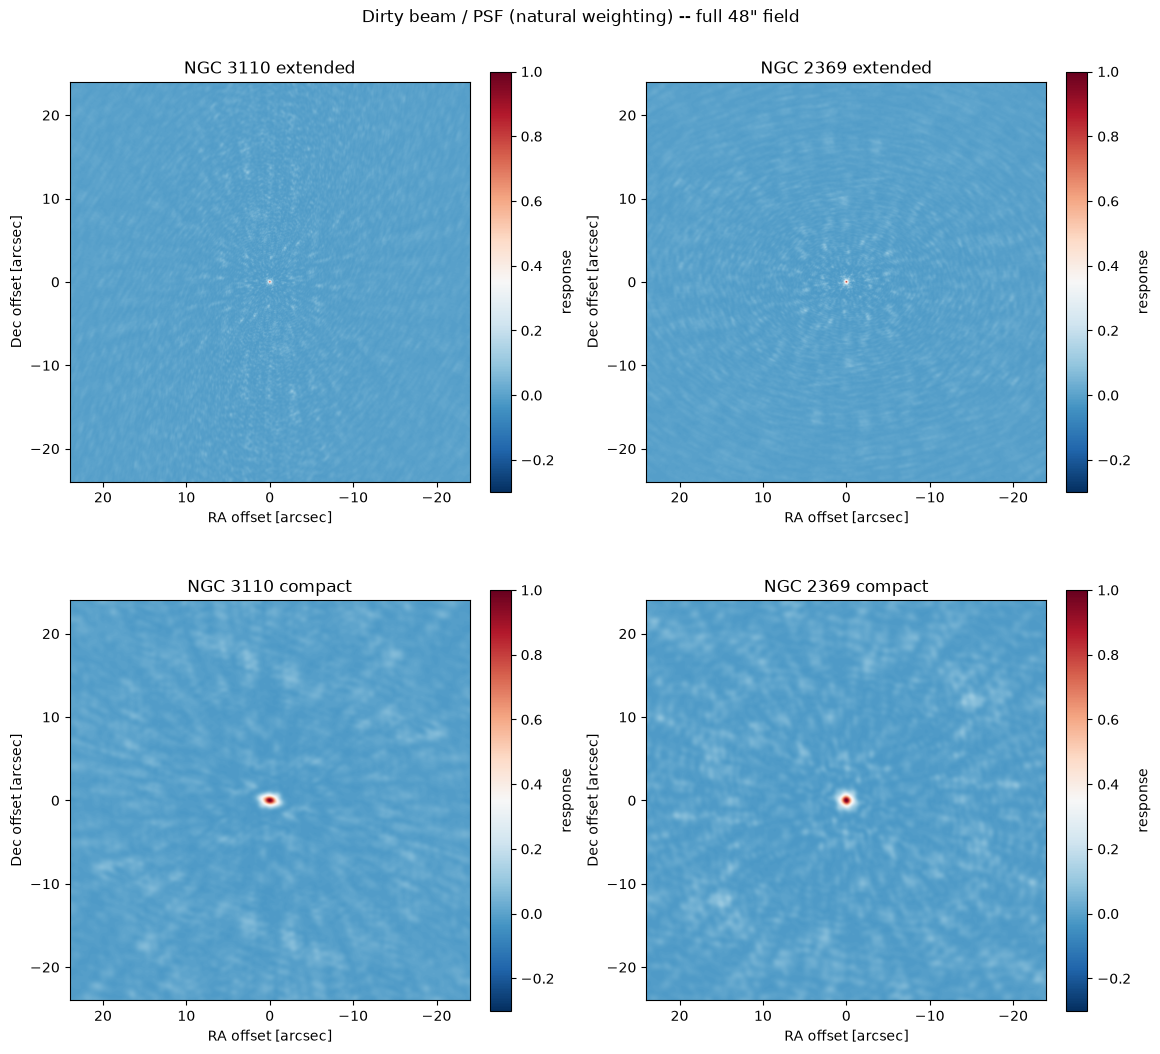

In [9]:
show_panels("psf", FULL_HALF, f"Dirty beam / PSF ({WEIGHTING} weighting) -- "
            f"full {2 * FULL_HALF:.0f}\" field", "response",
            cmap="RdBu_r", vmin=-0.3, vmax=1.0)

wrote /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc3110/extended/dirty_beam_16arcsec.fits
wrote /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc3110/compact/dirty_beam_16arcsec.fits
wrote /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc2369/extended/dirty_beam_16arcsec.fits
wrote /nas/homes/alahiry/repos/Deconvolver2D1D-ALMA/data/ngc2369/compact/dirty_beam_16arcsec.fits


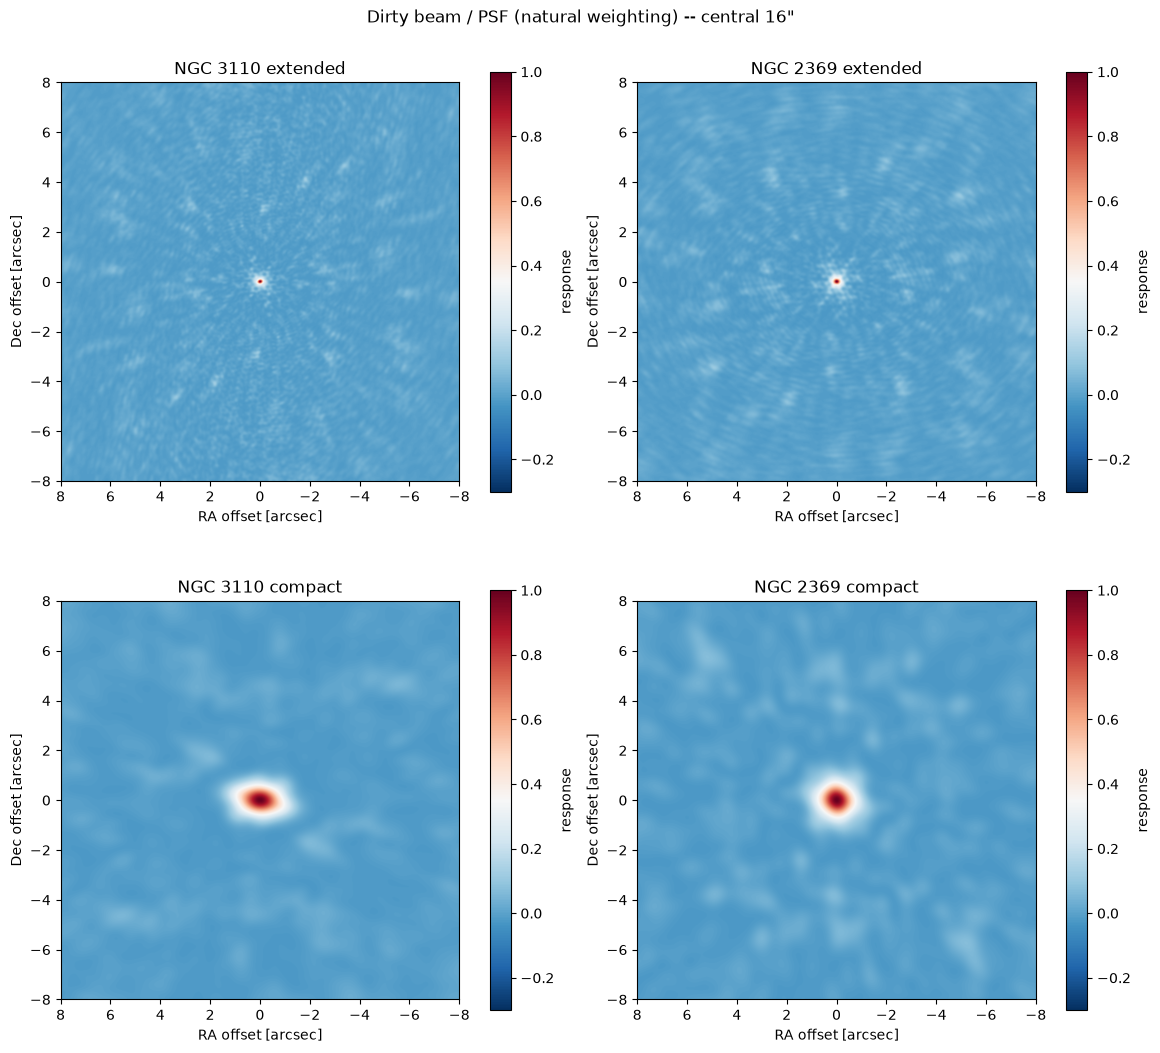

In [10]:
# Same beams, cropped to the central CROP_ARCSEC, also saved as FITS
# (dirty_beam_16arcsec.fits).
for (key, config), r in results.items():
    dst = r["fits"]["psf"].replace(".fits", f"_{CROP_ARCSEC:.0f}arcsec.fits")
    print("wrote", crop_fits(r["fits"]["psf"], dst, CROP_ARCSEC))

show_panels("psf", CROP_ARCSEC / 2, f"Dirty beam / PSF ({WEIGHTING} weighting) -- "
            f"central {CROP_ARCSEC:.0f}\"", "response",
            cmap="RdBu_r", vmin=-0.3, vmax=1.0)

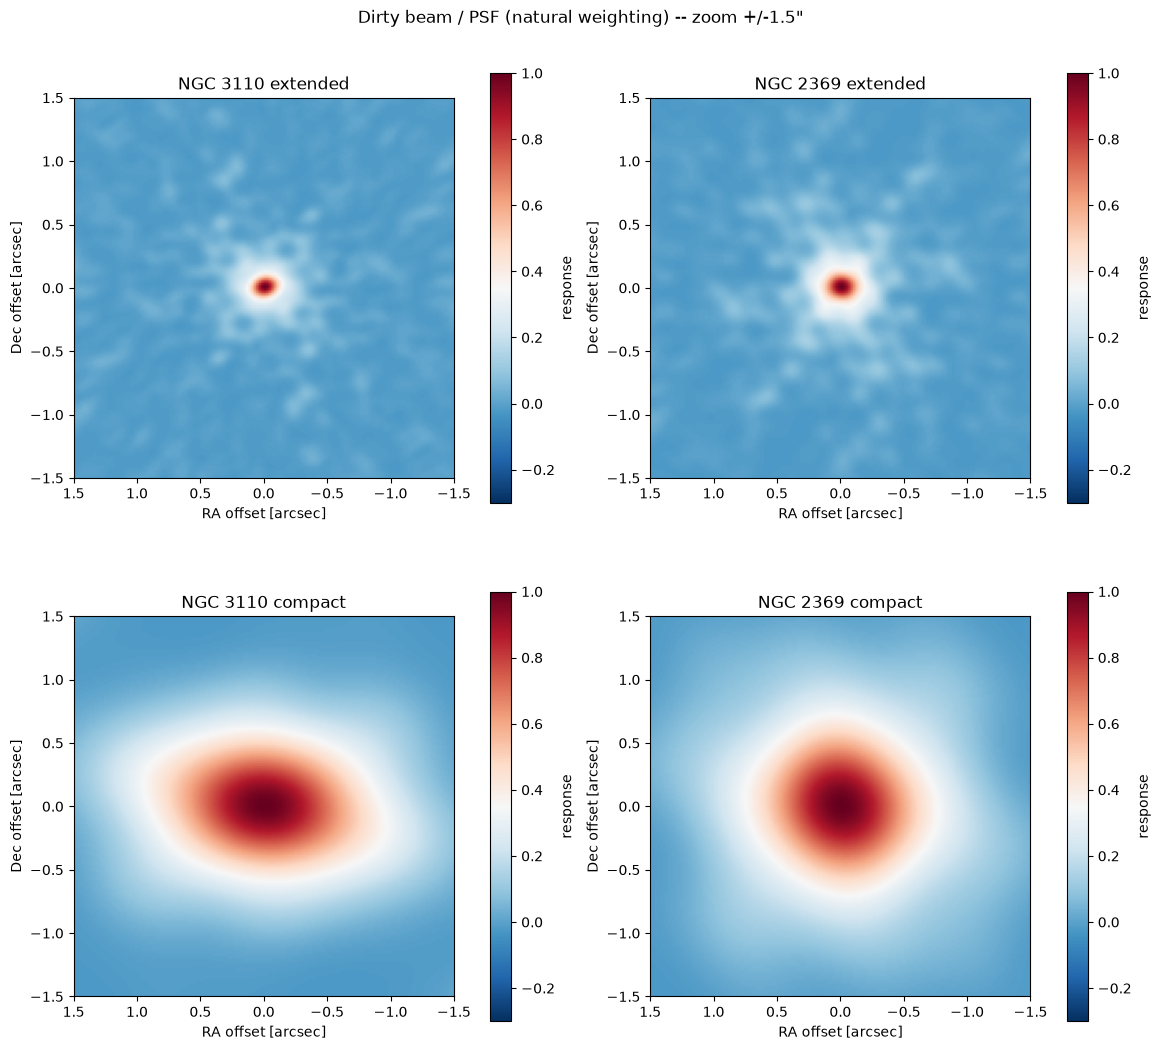

In [11]:
# Main-lobe zoom: the extended beam is ~0.15" across, invisible at 16".
show_panels("psf", PSF_ZOOM_ARCSEC, f"Dirty beam / PSF ({WEIGHTING} weighting) -- "
            f"zoom +/-{PSF_ZOOM_ARCSEC}\"", "response",
            cmap="RdBu_r", vmin=-0.3, vmax=1.0)

## FITS outputs

```
data/<galaxy>/<config>/dirty_image.fits            full 48" (2400 x 2400 px)
data/<galaxy>/<config>/dirty_beam.fits
data/<galaxy>/<config>/dirty_image_16arcsec.fits   central 16" (800 x 800 px)
data/<galaxy>/<config>/dirty_beam_16arcsec.fits
```

for `<galaxy>` in `ngc3110`, `ngc2369` and `<config>` in `extended`,
`compact` (NGC 3110 compact: 2 EBs gridded together). All share one pixel
grid per galaxy at 0.02", centred on the galaxy's (identical) phase centre in
every MS -- the 16" crops are exact sub-arrays of the full images, with the
phase centre still on the central pixel.

These are quick-look products only: one configuration each, continuum MFS,
natural weighting, no primary-beam correction, no CLEAN.